In [1]:
## CONNECT WITH GOOGLE DRIVE

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
## DATASET LOAD

df_bangla = open("/content/drive/MyDrive/FL paper/Dataset/main bangla corpus dataset.txt").read()

In [3]:
df_bangla

'\ufeffকর্পোরেশনের দোষ তো আছে । কিন্তু আমরা যে সুযোগ বুঝে হাজার হাজার কোটি টাকার ট্যাক্স ফাকি দিয়ে আসছি সেটাও আমরা জানি । এই ভয়ে সবাই স্যু করার সাহস পাবেনা । কারণ উলটা স্যু সে নিজে খেয়ে যাবে । আপনি স্যু করে দৃষ্টান্ত শুরু করে দিলেই পারেন । অন্যরাও ধীরে ধীরে উৎসাহিত হবে । পরিবর্তন আসবে । আমাদের সবার মনেই বিদেশে পড়তে যাওয়ার সুপ্ত কিন্তু তীব্র আকাঙ্ক্ষা কাজ করে । বিদেশে পড়ার ক্ষেত্রে খরচের ব্যাপারটা মাথায় আসে বলেই আমরা অনেকেই চাই বৃত্তি বা স্কলারশিপ এর ব্যাপারে খোঁজ নিতে । পুরো প্রক্রিয়াটি অনেক বিশদ হওয়ায় আমার ক্ষুদ্র অভিজ্ঞতা থেকে আমি চেষ্টা করবো আমার শিক্ষার্থীদের কিছুটা জানানোর । আমার লেখাটা টি পর্বে থাকবে । আজ প্রথম পর্ব । আজকে আমি আলোচনা করবো বাংলাদেশি শিক্ষার্থীদের জন্য বিদেশে পড়তে যাওয়ার স্কলারশিপ নিয়ে । পরবর্তীতে বিভিন্ন দেশে এপ্লাই করার প্রক্রিয়া ক্রেডিট ট্রান্সফার বিশ্ববিদ্যালয়ের ইন হাউস স্কলারশিপ ইত্যাদি বিষয়ে আলোচনা করবো । যুক্তরাজ্যে পড়তে যাওয়ার জন্য ব্রিটিশ সরকারের বৃত্তি এটি । অত্যন্ত সম্মানজনক এবং সেইসাথে খুবই প্রতিযোগিতামূলক । সাধারণত যারা শিক্ষকতা পেশায় নিয়োজিত থাকেন তার

In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import copy

from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical



import torch
import torchvision  # torch package for vision related things
import torch.nn.functional as F  # Parameterless functions, like (some) activation functions
import torchvision.datasets as datasets  # Standard datasets
import torchvision.transforms as transforms  # Transformations we can perform on our dataset for augmentation
from torch import optim  # For optimizers like SGD, Adam, etc.
from torch import nn  # All neural network modules
from torch.utils.data import Dataset,DataLoader # Gives easier dataset managment by creating mini batches etc.
from tqdm import tqdm  # For a nice progress bar!
import math
from torch.optim import Adam
from tqdm import tqdm, tqdm_notebook



import collections
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from torch.utils.data import TensorDataset
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score


In [5]:

class preprocess :


  def __init__(self,data):

    
    self.df_bangla=data
    self.X, self.Y , self.vocab_size = self.tokenize(self.replace_strings(self.df_bangla))


  
      



  def replace_strings(self,text):
      emoji_pattern = re.compile("["
                            u"\U0001F600-\U0001F64F"  # emoticons
                            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                            u"\U0001F680-\U0001F6FF"  # transport & map symbols
                            u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                            u"\U00002702-\U000027B0"
                            u"\U000024C2-\U0001F251"
                            u"\u00C0-\u017F"          #latin
                            u"\u2000-\u206F"          #generalPunctuations
                                
                            "]+", flags=re.UNICODE)
      english_pattern=re.compile('[a-zA-Z0-9]+', flags=re.I)
      
      
      text=emoji_pattern.sub(r'', text)
      text=english_pattern.sub(r'', text)
      

      return text


  def remove_punctuations(self,my_str):
      # define punctuation
      punctuations = '''````£|¢|Ñ+-*/=EROero৳০১২৩৪৫৬৭৮৯012–34567•89।!()-[]{};:'"“\’,<>./?@#$%^&*_~‘—॥”‰⚽️✌�￰৷￰'''

      
      
      no_punct = ""
      for char in my_str:
          if char not in punctuations:
              no_punct=no_punct+char

          
      no_punct = re.sub('\\s+', ' ', no_punct)
      
      # display the unpunctuated string
      return no_punct



  def tokenize (self,df_bangla):


    tokens = df_bangla.split()

    print('Number of words in text file :', len(tokens))


    # organize into sequences of tokens
    length = 5
    ban_sequences = list()
    for i in range(length, len(tokens)):
      # select sequence of tokens
      seq = tokens[i-length:i]
      # convert into a line
      line = ' '.join(seq)
      # store
      ban_sequences.append(line)
    print('Total Sequences: %d' % len(ban_sequences))


    # integer encode sequences of words
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(ban_sequences)
    sequences = tokenizer.texts_to_sequences(ban_sequences)

    sequences=pad_sequences(sequences,padding='pre',maxlen=length)

    # vocabulary size
    vocab_size = len(tokenizer.word_index) + 1
    print('Vocabulary Size: ',vocab_size)


    x_seq=[]
    y_seq=[]

    for s in sequences:

      

      x_seq.append(s[:-1])
      y_seq.append(s[-1])




    x_seq=np.array(x_seq)
    y_seq=np.array(y_seq)




    y_seq = to_categorical(y_seq, num_classes=vocab_size)


    


    return x_seq,y_seq,vocab_size













In [6]:
bangla_preprocess=preprocess(df_bangla)

print(bangla_preprocess.X[0])
print(bangla_preprocess.Y[0])
print(bangla_preprocess.vocab_size)

Number of words in text file : 58573
Total Sequences: 58568
Vocabulary Size:  8626
[8625 3458   54   24]
[0. 1. 0. ... 0. 0. 0.]
8626


In [7]:
NUM_CLASSES = bangla_preprocess.vocab_size #We are dealing with a multiclass classification of 5 classes
HIDDEN_DIM = 100 #number of neurons of the internal state (internal neural network in the LSTM)
LSTM_LAYERS = 1 #Number of stacked LSTM layers

VOCAB_SIZE=bangla_preprocess.vocab_size
EMBEDDING_DIM = 50


DROPOUT = 0.5 #LSTM Dropout
BIDIRECTIONAL = True #Boolean value to choose if to use a bidirectional LSTM or not

criterion = nn.CrossEntropyLoss()

batch_size = 64
epochs = 10
num_users = 10
frac = 1
args = {
    "batch_size" : 64,
    "num_clients": 10,
    "frac": 1,
    "ep_local": 5,
    "bs_local": 10,
    "epochs": 10,
    "dataset": "df_bangla",
    "model": "BI-LSTM",
    "iid": "iid",
    
    # Unlearning params
    "unlearned_clients": [0], 
    "t": 2, # calibration_interval,
    "r": 0.5 # local_calibration_epoch_ratio r = Ecali/Eloc
    
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
class DatasetSplit(Dataset):
    def __init__(self, dataset_train, idxs):
        self.dataset_train = dataset_train
        self.idxs = list(idxs)

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, item):
        image, label = self.dataset_train[self.idxs[item]]
        return image, label

In [9]:
X_train, X_test, y_train, y_test = train_test_split(bangla_preprocess.X, bangla_preprocess.Y, test_size=0.2, random_state= 42)

In [10]:


# Loading data using torchvision.datasets
dataset_train = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))

dataset_test = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))


# Creating a pytorch loader for a Deep Learning model
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, drop_last=True)

test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=True, drop_last=True)


# Non Distribute data - NON_IID

num_items=[5,6,10,14,7,11,14,20,8,5]

for idx,i in enumerate(num_items):

  num_items[idx]= int((len(dataset_train)*i)/100)



  
dict_users, all_idxs = {}, [i for i in range(len(dataset_train))]
for i in range(args["num_clients"]):
    dict_users[i] = set(np.random.choice(all_idxs, num_items[i], replace=False))
    all_idxs = list(set(all_idxs) - dict_users[i])
    
    
local_datasets = []
for i in range(args["num_clients"]):
    local_datasets.append(DataLoader(DatasetSplit(dataset_train, dict_users[i]),
                                 batch_size=args["bs_local"], shuffle=True))

In [11]:
class Net(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, lstm_layers, bidirectional,batch_size, dropout):
        super(Net,self).__init__()
        
        self.lstm_layers = lstm_layers
        self.num_directions = 2 if bidirectional else 1
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes
        self.batch_size = batch_size
        

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=lstm_layers,
                            dropout=dropout,
                            bidirectional=bidirectional,
                            batch_first=True)

        self.fc = nn.Linear(hidden_dim*self.num_directions, num_classes)
        self.softmax = nn.LogSoftmax(dim=1)
        
    def forward(self, x, hidden):

        
        self.batch_size = x.size(0)
        ##EMBEDDING LAYER
        embedded = self.embedding(x)
        #LSTM LAYERS
        out, hidden = self.lstm(embedded, hidden)
        #Extract only the hidden state from the last LSTM cell
        out = out[:,-1,:]
        #FULLY CONNECTED LAYERS
        out = self.fc(out)
        out = self.softmax(out)

        return out,hidden

    def init_hidden(self, batch_size):
        #Initialization of the LSTM hidden and cell states
        h0 = torch.zeros((self.lstm_layers*self.num_directions, batch_size, self.hidden_dim)).detach().to(device)
        c0 = torch.zeros((self.lstm_layers*self.num_directions, batch_size, self.hidden_dim)).detach().to(device)
        hidden = (h0, c0)
        return hidden

In [12]:
class Client:
    num_clients = 0
    def __init__(self, data):
        self.id = Client.num_clients
        self.dataloader = data
        self.__model = None
        self.model_record = []
        self.device = device
        self.unlearned = False
        Client.num_clients += 1
        
        
    def setup(self, args):
        self.local_epoch = args["ep_local"]
        
        
    @property
    def unlearned(self):
        return self.__unlearned
    
    
    @unlearned.setter
    def unlearned(self, unlearned):
        self.__unlearned = unlearned
        
        
    @property
    def model(self):
        return self.__model
    
    
    @model.setter
    def model(self, model):
        self.__model = model


    def client_preprocess(data):

      client_preprocessed=preprocess(data)

      return client_preprocessed
        
        
    def client_update(self):
        self.model.train()
        self.model.to(self.device)

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=0.01, weight_decay = 5e-6)
        epoch_loss = []
        
        for epoch in range(self.local_epoch):
            batch_loss = []
            
            for batch_idx, (data, labels) in enumerate(self.dataloader):
                data, labels = data.to(self.device), labels.to(self.device)
                h = self.model.init_hidden(labels.size(0))
                self.model.zero_grad()
                outputs, h = self.model(data,h)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step() 


                
                batch_loss.append(loss.item())
            
            
            epoch_loss.append(sum(batch_loss)/len(batch_loss))

        
        return self.model, sum(epoch_loss) / len(epoch_loss)
    
    
    def client_test(self):
        self.model.eval()
        self.model.to(self.device)
        test_loss, correct = 0, 0
        with torch.no_grad():
            for data, labels in self.dataloader:
                data, labels = data.to(self.device), labels.to(self.device)

                val_h = self.model.init_hidden(labels.size(0))

                outputs, val_h = self.model(data, val_h)
                test_loss += criterion(outputs, labels).item()
                predicted = outputs.argmax(dim=1, keepdim=True)
                predicted.squeeze().tolist()
                predicted = torch.from_numpy(to_categorical(predicted, num_classes=bangla_preprocess.vocab_size))
                correct += torch.sum(predicted==labels).item()


        test_loss /= len(self.dataloader.dataset)
        test_accuracy = correct / len(self.dataloader.dataset)

        print(f"Average loss: {test_loss:.6f}, Accuracy: {(test_accuracy/100):.6f}%")

        return test_accuracy, test_loss


In [13]:
class Server:
    def __init__(self):
        self.round = 0
        self.model = Net(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM,NUM_CLASSES, LSTM_LAYERS,BIDIRECTIONAL, batch_size, DROPOUT).to(device)
        self.w_glob = None
        self.device = device
        
        self.history = {
            "train_loss": [], 
            "test_loss": [], 
            "train_acc": [],
            "test_acc": [],
            "avg_client_loss": [],
            "avg_client_acc":[]
        }
        
        
    def setup(self, args):
        self.train_loader = train_loader
        self.test_loader = test_loader
        
        self.num_clients = args["num_clients"]
        self.num_rounds = args["epochs"]
        self.local_epochs = args["ep_local"]
        self.batch_size = args["batch_size"]
        self.clients = args["clients"]
        self.unlearned_clients = args["unlearned_clients"]
        
        self.local_model_record = [[] for i in range(self.num_clients)]
        self.global_model_record = []
        
        
    def fedAvg(self, w):
        w_avg = copy.deepcopy(w[0])
        for k in w_avg.keys():
            for i in range(1, len(w)):
                w_avg[k] += w[i][k]
            w_avg[k] = torch.div(w_avg[k], len(w))
        self.model
        return w_avg
    
    
    def send_global_model(self):
        for client in self.clients:
            #client.w_local = copy.deepcopy(self.w_glob)
            client.model = copy.deepcopy(self.model)
            client.model_record.append(client.model)
        
        
    def train_global_model(self):
        w_locals = [self.w_glob for i in range(self.num_clients)]
        loss_locals = [0 for i in range(self.num_clients)]
        
        # Send global model to clients
        self.send_global_model()
        print("Send global model to all clients...")
        
        # Train local model
        acc_test_clients, loss_test_clients = [], []
        for id, client in enumerate(self.clients):
            print(f"\nUpdating client {id}...")
            local_model, loss_train_client = client.client_update()
            
            # Save local models
            self.local_model_record[id].append(local_model)
            w_locals.append(local_model.state_dict())
            #print(w_locals)
            loss_locals.append(loss_train_client)
            
            print(f"\nEvaluating client {id}...")
            acc_test_client, loss_test_client = client.client_test()
            acc_test_clients.append(acc_test_client)
            loss_test_clients.append(loss_test_client)
            
            
        # Fed Aggregation
        w_glob = self.fedAvg(w_locals)
            
        # Update global model
        self.model.load_state_dict(w_glob)
            
        return acc_test_clients, loss_locals
    
    
    def federated_learning(self):
        self.model.train()
        self.w_glob = self.model.state_dict()
        
        print("\tFederated Learning:")
        for round in tqdm(range(self.num_rounds)):
            self.round = round + 1
            print(f"\nRound {self.round}/{self.num_rounds}: Starting...")
            acc_train_clients, loss_train_clients = self.train_global_model()
            self.history["train_acc"].append(100*sum(acc_train_clients)/len(acc_train_clients))
            self.history["train_loss"].append(sum(loss_train_clients)/len(loss_train_clients))
            
            print(f"\nRound {self.round}: Evaluating...")
            # Save test accuracy and loss
            acc_test_server, loss_test_server = self.test_global_model()
            self.history["test_acc"].append(acc_test_server)
            self.history["test_loss"].append(loss_test_server)

            client_loss=sum(loss_train_clients) / len(loss_train_clients)
            client_acc="%.6f" %((sum(acc_train_clients)/len(acc_train_clients))/100)
            
            print(f"|---- Average Clients Loss: {client_loss}")
            self.history["avg_client_loss"].append(client_loss)
            print(f"|---- Average Clients Accuracy: {(sum(acc_train_clients)/len(acc_train_clients))/100:.6f}%")
            self.history["avg_client_acc"].append(client_acc)
            print(f"|---- Server Testing Accuracy: {acc_test_server/100:.6f}%")
            
            print(f"\nRound {self.round}: Finished!\n")
            print(f"---------------------------------")
            
        
        self.plot(self.history)
        
        
    
            
            
    def plot(self,history):


        print(f"\n Server loss Plot \n")
        
        plt.plot(history["test_loss"], color='c', label="Testing Loss")
        plt.title('Average Server test loss')
        plt.ylabel('Loss')
        plt.xlabel('Communication Round')
        plt.legend(['Test Loss'], loc='upper left')
        plt.show()
        print(f"\n---------------------------------\n")

        print(f"\n Server Accuracy Plot \n")
        
        
        plt.plot(history["test_acc"], color='c', label="Testing Accuracy")
        plt.title('Average Server test accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Communication Round')
        plt.legend(['Test Accuracy'], loc='upper left')
        plt.show()
        print(f"\n---------------------------------\n")

        print(f"\n Client Loss Plot \n")
        
        
        plt.plot(history["avg_client_loss"], color='c', label="Testing Loss")
        plt.title('Average Client test loss')
        plt.ylabel('Loss')
        plt.xlabel('Communication Round')
        plt.legend(['Test Loss'], loc='upper left')
        plt.show()

        print(f"\n---------------------------------\n")


        print(f"\n Client Accuracy Plot \n")
        
        
        plt.plot(history["avg_client_acc"], color='c', label="Testing Accuracy")
        plt.title('Average Client test accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Communication Round')
        plt.legend(['Test Accuracy'], loc='upper left')
        plt.show()

        print(f"\n---------------------------------\n")
        
        
        
        
    def test_global_model(self):
        self.model.eval()
        
        test_loss = 0
        correct = 0
        with torch.no_grad():
            for data, labels in self.test_loader:
                data, labels = data.to(self.device), labels.to(self.device)
                val_h = self.model.init_hidden(labels.size(0))
                output, val_h = self.model(data, val_h)
                test_loss += criterion(output, labels).item()  
                pred = output.argmax(dim=1, keepdim=True)  
                pred.squeeze().tolist()
                pred = torch.from_numpy(to_categorical(pred , num_classes=bangla_preprocess.vocab_size))
                correct += torch.sum(pred==labels).item()
                


        test_loss /= len(self.test_loader.dataset)
        accuracy = correct / len(self.test_loader.dataset)
        

        
        print(f"\nAverage loss: {test_loss:.6f}, Accuracy: { accuracy/100:.6f}%")

        return accuracy, test_loss
    
    

   

In [14]:
# Create clients and distribute the dataset 
# All clients are stored in list clients
args["clients"] = []
for i in range(args["num_clients"]):
    client = Client(local_datasets[i])
    client.setup(args)
    args["clients"].append(client)
    
for unlearned in args["unlearned_clients"]:
    args["clients"][unlearned].unlearned = True

In [15]:
# Create a server
server = Server()
server.setup(args)

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/rnn.py:65: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  "num_layers={}".format(dropout, num_layers))


	Federated Learning:


  0%|          | 0/10 [00:00<?, ?it/s]


Round 1/10: Starting...
Send global model to all clients...

Updating client 0...

Evaluating client 0...
Average loss: 0.002609, Accuracy: 86.259906%

Updating client 1...

Evaluating client 1...
Average loss: 0.002950, Accuracy: 86.259936%

Updating client 2...

Evaluating client 2...
Average loss: 0.013237, Accuracy: 86.259398%

Updating client 3...

Evaluating client 3...
Average loss: 0.020560, Accuracy: 86.259088%

Updating client 4...

Evaluating client 4...
Average loss: 0.004855, Accuracy: 86.259805%

Updating client 5...

Evaluating client 5...
Average loss: 0.015424, Accuracy: 86.259305%

Updating client 6...

Evaluating client 6...
Average loss: 0.026989, Accuracy: 86.258707%

Updating client 7...

Evaluating client 7...
Average loss: 0.041808, Accuracy: 86.257964%

Updating client 8...

Evaluating client 8...
Average loss: 0.006721, Accuracy: 86.259728%

Updating client 9...

Evaluating client 9...
Average loss: 0.003815, Accuracy: 86.259846%

Round 1: Evaluating...


 10%|█         | 1/10 [10:52<1:37:54, 652.70s/it]


Average loss: 0.126005, Accuracy: 86.226717%
|---- Average Clients Loss: 1.7766435404195842
|---- Average Clients Accuracy: 86.259368%
|---- Server Testing Accuracy: 86.226717%

Round 1: Finished!

---------------------------------

Round 2/10: Starting...
Send global model to all clients...

Updating client 0...

Evaluating client 0...
Average loss: 0.000861, Accuracy: 86.259983%

Updating client 1...

Evaluating client 1...
Average loss: 0.001010, Accuracy: 86.259979%

Updating client 2...

Evaluating client 2...
Average loss: 0.003973, Accuracy: 86.259876%

Updating client 3...

Evaluating client 3...
Average loss: 0.013762, Accuracy: 86.259421%

Updating client 4...

Evaluating client 4...
Average loss: 0.001781, Accuracy: 86.259939%

Updating client 5...

Evaluating client 5...
Average loss: 0.006246, Accuracy: 86.259767%

Updating client 6...

Evaluating client 6...
Average loss: 0.015067, Accuracy: 86.259369%

Updating client 7...

Evaluating client 7...
Average loss: 0.033641,

...


Average loss: 0.124446, Accuracy: 86.227710%
|---- Average Clients Loss: 1.0697120524363417
|---- Average Clients Accuracy: 86.259832%
|---- Server Testing Accuracy: 86.227710%

Round 8: Finished!

---------------------------------

Round 9/10: Starting...
Send global model to all clients...

Updating client 0...

Evaluating client 0...
Average loss: 0.000799, Accuracy: 86.259991%

Updating client 1...

Evaluating client 1...
Average loss: 0.000484, Accuracy: 86.259993%

Updating client 2...

Evaluating client 2...
Average loss: 0.001323, Accuracy: 86.259979%

Updating client 3...

Evaluating client 3...
Average loss: 0.005740, Accuracy: 86.259841%

Updating client 4...

Evaluating client 4...
Average loss: 0.000772, Accuracy: 86.259988%

Updating client 5...

Evaluating client 5...
Average loss: 0.002259, Accuracy: 86.259946%

Updating client 6...

Evaluating client 6...
Average loss: 0.005911, Accuracy: 86.259814%

Updating client 7...

Evaluating client 7...
Average loss: 0.026562,

 90%|█████████ | 9/10 [1:35:07<10:32, 632.49s/it]


Average loss: 0.127352, Accuracy: 86.227835%
|---- Average Clients Loss: 1.0718576836694906
|---- Average Clients Accuracy: 86.259824%
|---- Server Testing Accuracy: 86.227835%

Round 9: Finished!

---------------------------------

Round 10/10: Starting...
Send global model to all clients...

Updating client 0...

Evaluating client 0...
Average loss: 0.000501, Accuracy: 86.259991%

Updating client 1...

Evaluating client 1...
Average loss: 0.000242, Accuracy: 86.260000%

Updating client 2...

Evaluating client 2...
Average loss: 0.000800, Accuracy: 86.259987%

Updating client 3...

Evaluating client 3...
Average loss: 0.004674, Accuracy: 86.259851%

Updating client 4...

Evaluating client 4...
Average loss: 0.000678, Accuracy: 86.259988%

Updating client 5...

Evaluating client 5...
Average loss: 0.002287, Accuracy: 86.259946%

Updating client 6...

Evaluating client 6...
Average loss: 0.004290, Accuracy: 86.259872%

Updating client 7...

Evaluating client 7...
Average loss: 0.024093

100%|██████████| 10/10 [1:45:38<00:00, 633.88s/it]


Average loss: 0.130108, Accuracy: 86.227934%
|---- Average Clients Loss: 1.076965899782802
|---- Average Clients Accuracy: 86.259844%
|---- Server Testing Accuracy: 86.227934%

Round 10: Finished!

---------------------------------

 Server loss Plot 



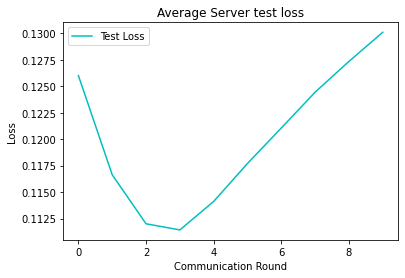


---------------------------------


 Server Accuracy Plot 



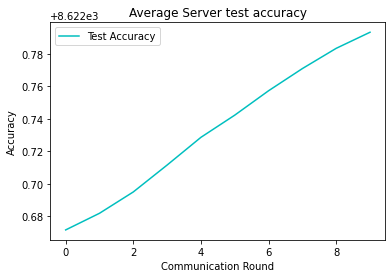


---------------------------------


 Client Loss Plot 



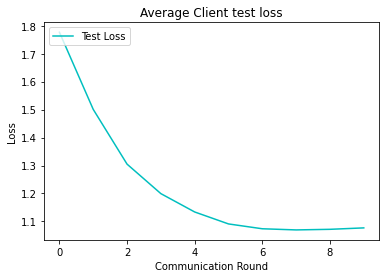


---------------------------------


 Client Accuracy Plot 



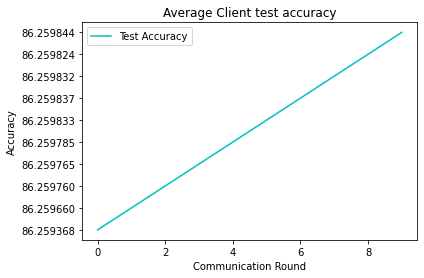


---------------------------------



In [16]:
server.federated_learning()

In [17]:
server.history

{'avg_client_acc': ['86.259368',
  '86.259660',
  '86.259760',
  '86.259765',
  '86.259785',
  '86.259833',
  '86.259837',
  '86.259832',
  '86.259824',
  '86.259844'],
 'avg_client_loss': [1.7766435404195842,
  1.5007384887244297,
  1.3049469774307492,
  1.1994676832991338,
  1.1338716224090508,
  1.0911022813967697,
  1.0738205307818334,
  1.0697120524363417,
  1.0718576836694906,
  1.076965899782802],
 'test_acc': [8622.6716749189,
  8622.681919071198,
  8622.695065733311,
  8622.711627112856,
  8622.728700700018,
  8622.742359569746,
  8622.757384326447,
  8622.771043196175,
  8622.783506914802,
  8622.793409595355],
 'test_loss': [0.12600537744300325,
  0.11663534390106123,
  0.11200533947969879,
  0.11142662822416624,
  0.11412153436153726,
  0.11770900276428974,
  0.12105812842434373,
  0.12444581121679497,
  0.127351571130777,
  0.13010773427538933],
 'train_acc': [862593.6834353348,
  862596.599095939,
  862597.6025601167,
  862597.6467759967,
  862597.8476334398,
  862598.334

In [38]:
def plot(history):



        print(f"\n Average of clients loss Plot \n")
        
        plt.plot(history["avg_client_loss"], color='c', label="Testing Loss")
        
        plt.title('Average of clients test loss')
        plt.ylabel('Loss')
        plt.xlabel('Communication Round')
        plt.legend(['Test Loss'], loc='upper right')
        plt.show()
        
        print(f"\n---------------------------------\n")

        print(f"\n Server Accuracy Plot \n")

        plt.plot(history["test_acc"], color='c', label="Testing Accuracy")
        
        plt.title('Server Accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Communication Round')
        plt.legend(['Test Accuracy'], loc='upper left')
        plt.show()
        
        print(f"\n---------------------------------\n")
        
        
        


 Average of clients loss Plot 



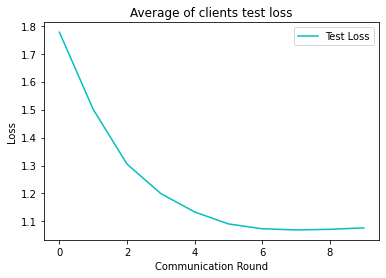


---------------------------------


 Server Accuracy Plot 



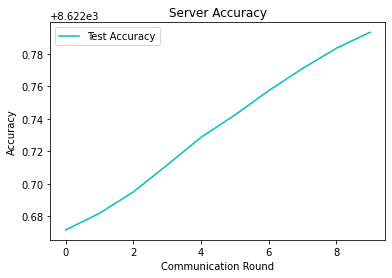


---------------------------------



In [39]:
plot(server.history)